<a href="https://colab.research.google.com/github/leticiabbacellar/Python/blob/main/Predicao_estresse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df_stress = df[["Age", "Quality of Sleep", "Physical Activity Level", "Stress Level", "Daily Steps"]]
df_stress.head()

,Age,Quality of Sleep,Physical Activity Level,Stress Level,Daily Steps
0,27,6,42,6,4200
1,28,6,60,8,10000
2,28,6,60,8,10000
3,28,4,30,8,3000
4,28,4,30,8,3000


In [4]:
X= df_stress[["Age","Quality of Sleep", "Physical Activity Level", "Daily Steps"]]
y= df_stress["Stress Level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

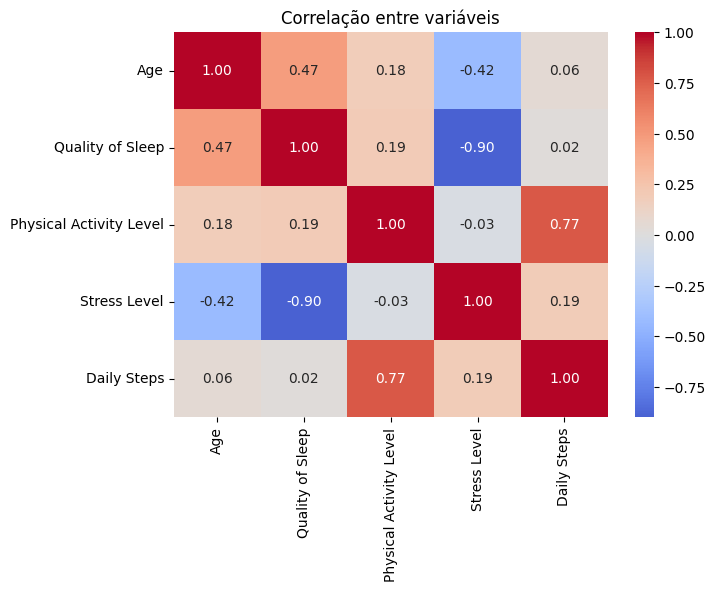

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(df_stress.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis')
plt.show()

In [6]:
modelo_stress = make_pipeline (
    StandardScaler(),
    LinearRegression() )
modelo_stress.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [7]:
y_pred= modelo_stress.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

Erro Médio Absoluto (MAE): 0.45
Coeficiente de Determinação (R²): 0.87


/tmp/ipykernel_32922/1173001828.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Impacto', y='Variável', palette='viridis')


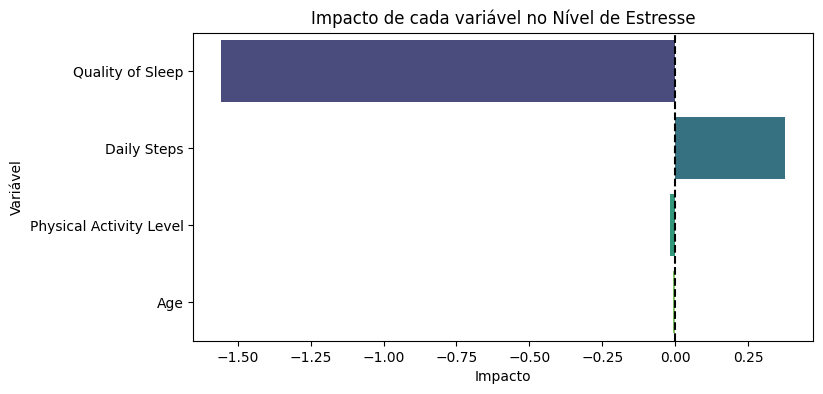

In [11]:
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Impacto': modelo_stress.named_steps['linearregression'].coef_
}).sort_values(by='Impacto', key=abs, ascending=False)


plt.figure(figsize=(8, 4))
sns.barplot(data=coef_df, x='Impacto', y='Variável', palette='viridis')
plt.title('Impacto de cada variável no Nível de Estresse')
plt.axvline(0, color='black', linestyle='--')
plt.show()

/tmp/ipykernel_32922/1338998528.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[0].scatter(y_test, y_pred, alpha=0.5, s=25, cmap='viridis')
/tmp/ipykernel_32922/1338998528.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[1].scatter(y_pred, residuos, alpha=0.5, s=25, cmap='viridis')


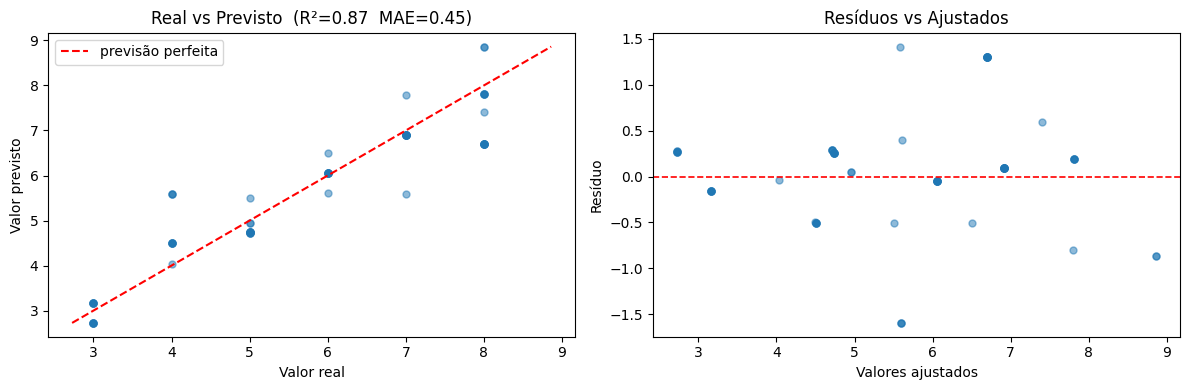

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Real vs Previsto
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].scatter(y_test, y_pred, alpha=0.5, s=25, cmap='viridis')
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='previsão perfeita')
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Valor previsto")
axes[0].set_title(f"Real vs Previsto  (R²={r2:.2f}  MAE={mae:.2f})")
axes[0].legend()

# 2. Resíduos vs Ajustados
residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.5, s=25, cmap='viridis')
axes[1].axhline(0, color='red', lw=1.2, ls='--')
axes[1].set_xlabel("Valores ajustados")
axes[1].set_ylabel("Resíduo")
axes[1].set_title("Resíduos vs Ajustados")

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores  = cross_val_score(modelo_stress, X, y, cv=kf, scoring='r2')
mae_scores = cross_val_score(modelo_stress, X, y, cv=kf, scoring='neg_mean_absolute_error')
mae_scores = -mae_scores

print("── R² por fold ──")
for i, v in enumerate(r2_scores, 1):
    print(f"  Fold {i}: {v:.3f}")
print(f"  Média: {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")

print("\n── MAE por fold ──")
for i, v in enumerate(mae_scores, 1):
    print(f"  Fold {i}: {v:.3f}")
print(f"  Média: {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")

── R² por fold ──
  Fold 1: 0.867
  Fold 2: 0.885
  Fold 3: 0.865
  Fold 4: 0.792
  Fold 5: 0.803
  Média: 0.842 ± 0.038

── MAE por fold ──
  Fold 1: 0.446
  Fold 2: 0.423
  Fold 3: 0.433
  Fold 4: 0.573
  Fold 5: 0.527
  Média: 0.480 ± 0.059
